In [2]:
import sympy as sy
import numpy as np
import matplotlib.pyplot as plt, mpld3
import matplotlib as mpl
# %matplotlib widget
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']
# mpld3.enable_notebook()
import skimage
from skimage import io
import scipy

if mpl.rcParams["figure.facecolor"] == "black":
    mpl.rcParams["figure.facecolor"] = (41/255, 45/255, 62/255, 1)
    mpl.rcParams["axes.facecolor"] = (41/255, 45/255, 62/255, 1)


In [3]:
%%html
<style>
.cell-output-ipywidget-background {
   background-color: transparent !important;
}
.jp-OutputArea-output {
   background-color: transparent;
}  
.mpld3-text {
   fill: black !important;
}
.mpld3-axesbg {
   fill: #ffffff00 !important
}
</style>

# L02

## E 6.1

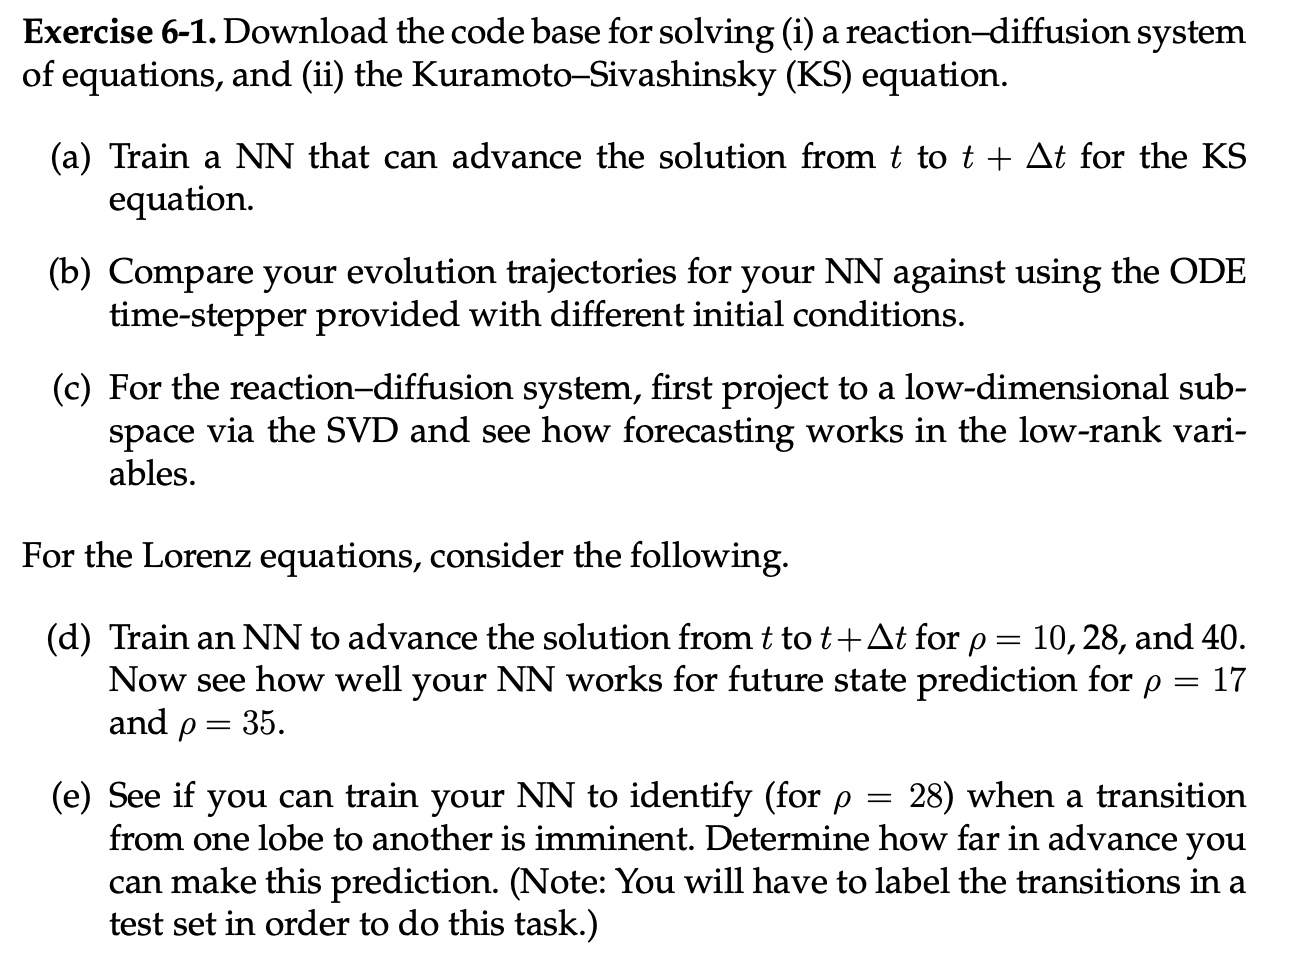

## E 6.3

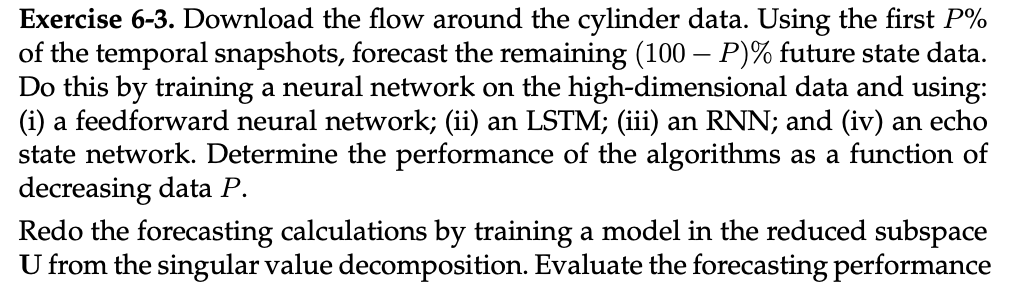

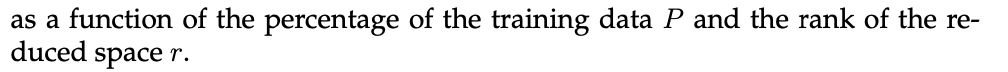

### Neural network

In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

In [80]:
class CustomDatasetNN(Dataset):
    def __init__(self, P, test = False, r=10):
        data = scipy.io.loadmat("./dmdbook_data/FLUIDS/CYLINDER_ALL.mat")

        u_all = data["UALL"].astype(float)

        U, Sigma, Vt = np.linalg.svd(u_all, full_matrices=False)

        self.U = U[:,0:r]

        num_data = u_all.shape[1] - 1
        self.im_shape = (449,199)

        num = int(num_data * P)
        if test == False:
            self.data = u_all[:,:num]
        else:
            self.data = u_all[:,num:]

    def __len__(self):
        return self.data.shape[1] - 1

    def __getitem__(self, idx):
        x = self.U.T @ self.data[:,idx]
        y = self.U.T @ self.data[:,idx + 1]
        return x, y
    


class CustomDatasetRNN(Dataset):
    def __init__(self, P, test = False, r=10, num_input = 10):
        self.num_input = num_input
        self.im_shape = (449,199)

        data = scipy.io.loadmat("./dmdbook_data/FLUIDS/CYLINDER_ALL.mat")

        u_all = data["UALL"].astype(float)

        U, Sigma, Vt = np.linalg.svd(u_all, full_matrices=False)

        self.U = U[:,0:r]

        num_data = u_all.shape[1] - num_input

        num = int(num_data * P)
        if test == False:
            self.data = u_all[:,:num]
        else:
            self.data = u_all[:,num:]

    def __len__(self):
        return self.data.shape[1] - self.num_input

    def __getitem__(self, idx):
        x = self.U.T @ self.data[:,idx:idx+self.num_input]
        y = self.U.T @ self.data[:,idx + self.num_input]
        return x.T, y
    
    

In [106]:
r = 20
batch_size = 40
P = 0.9
num_input = 5
# training_data = CustomDatasetNN(P=P, r=r)
# test_data = CustomDatasetNN(P=P, test=True, r=r)


training_data = CustomDatasetRNN(P=P, r=r, num_input=num_input)
test_data = CustomDatasetRNN(P=P, test=True, r=r, num_input=num_input)

train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

In [107]:
class NeuralNetwork(nn.Module):
    def __init__(self, r=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(r, 5120).double(),
            nn.ReLU(),
            nn.Linear(5120, 5120).double(),
            nn.ReLU(),
            nn.Linear(5120, 5120).double(),
            nn.ReLU(),
            nn.Linear(5120, 5120).double(),
            nn.ReLU(),
            nn.Linear(5120, 5120).double(),
            nn.ReLU(),
            nn.Linear(5120,r).double(),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits
    

class RNN(nn.Module):
    def __init__(self, r=10, num_input=10, size_hidden=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.h0 = torch.rand(1, num_input, r).double()
        self.rnn = nn.RNN(r, r).double()

    def forward(self, x):
        # x = x = self.flatten(x)
        output, hn = self.rnn(x,self.h0)
        return output[:,-1,:]
    

model = RNN(r=r, num_input=num_input).to("cpu")

In [115]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-10)

In [116]:

losses = []

def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to("cpu"), y.to("cpu")

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        losses.append(loss)
        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 50 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [117]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to("cpu"), y.to("cpu")
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
    test_loss /= num_batches
    print(f"Test Error: Avg loss: {test_loss:>8f} \n")

In [118]:
losses = []
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 3636.415674  [   10/  126]
Test Error: Avg loss: 3641.525640 

Epoch 2
-------------------------------
loss: 3636.415674  [   10/  126]
Test Error: Avg loss: 3641.525640 

Epoch 3
-------------------------------
loss: 3636.415674  [   10/  126]
Test Error: Avg loss: 3641.525640 

Epoch 4
-------------------------------
loss: 3636.415674  [   10/  126]
Test Error: Avg loss: 3641.525640 

Epoch 5
-------------------------------
loss: 3636.415674  [   10/  126]
Test Error: Avg loss: 3641.525640 

Epoch 6
-------------------------------
loss: 3636.415674  [   10/  126]
Test Error: Avg loss: 3641.525640 

Epoch 7
-------------------------------
loss: 3636.415674  [   10/  126]
Test Error: Avg loss: 3641.525640 

Epoch 8
-------------------------------
loss: 3636.415674  [   10/  126]
Test Error: Avg loss: 3641.525640 

Epoch 9
-------------------------------
loss: 3636.415674  [   10/  126]
Test Error: Avg loss: 3641.525640 

Epoch 10
----------

Text(0, 0.5, 'MSE loss')

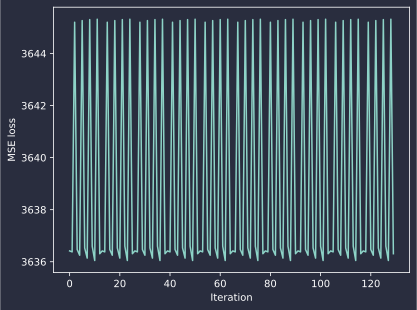

In [119]:
plt.plot([float(x) for x in losses])
plt.xlabel("Iteration")
plt.ylabel("MSE loss")

In [120]:
X,y = enumerate(train_dataloader).__next__()[1]

In [121]:
X.shape

torch.Size([10, 5, 20])

In [122]:
pred = model(X).detach().numpy().T
pred.shape

(20, 10)

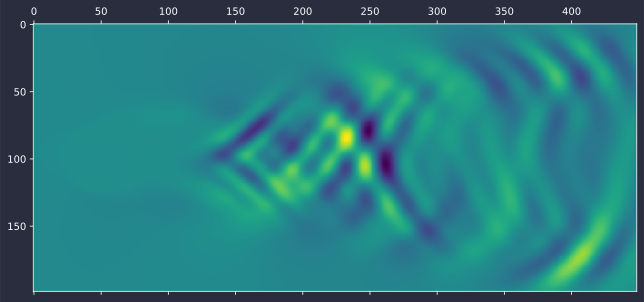

In [123]:
plt.matshow((training_data.U @ pred[:,0]).reshape((449,199)).T)

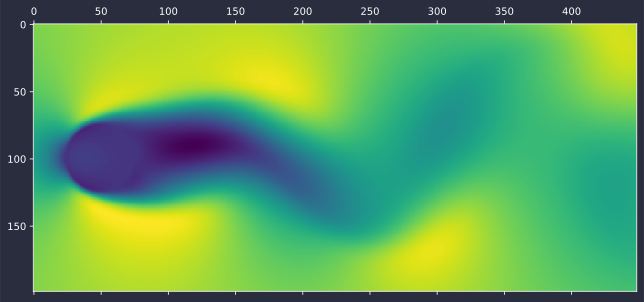

In [124]:
plt.matshow((training_data.U @ y[0].detach().numpy().T).reshape((449,199)).T)

### RNN